In [1]:
import pandas as pd
import pickle as pkl
import os
import numpy as np

In [2]:
# Let's adjust the broadcasting to handle the matrix dimensions correctly during normalization
def att_score(A):
    """
    Args:
    A (numpy.ndarray): Input matrix of shape (no_layers * no_heads, L, L).
    
    Returns:
    numpy.ndarray: The final attention vector of length L.
    """
    
    # Step 1: Make the matrix symmetric by adding its transpose
    if A.ndim < 3:
        A = np.expand_dims(A, axis=0)
    A_symmetric = A + A.transpose(0, 2, 1)
    
    # Step 2: Normalize the symmetric matrix
    sum_i = np.sum(A_symmetric, axis=1)  # Sum across rows
    sum_j = np.sum(A_symmetric, axis=2)  # Sum across columns
    sum_total = np.sum(A_symmetric)  # Sum of all elements
    
    # Compute the average value broadcast across elements
    avg_value = (sum_i[:, :, None] @ sum_j[:, None, :]) / sum_total  # Reshaping for broadcasting
    A_normalized = A_symmetric - avg_value  # Element-wise subtraction
    
    # Step 3: Sum along the no_layers * no_heads dimension
    A_reduced = np.sum(A_normalized, axis=0)
    
    # Step 4: Sum along the rows to generate the final attention vector
    attention_vector = np.sum(A_reduced, axis=0)
    
    return attention_vector

In [3]:
def get_gene_att_score(res_dir, data_name):
    
    with open(os.path.join(res_dir, f"{data_name}_crossatt.pkl"), 'rb') as f: 
        cross_att_all = pkl.load(f)
    with open(os.path.join(res_dir, f"{data_name}_transformeratt.pkl"), 'rb') as f: 
        trans_att_all = pkl.load(f)

    cross_att_vec = []
    for att_part in range(4):
        att_folds = []
        for fold in range(len(cross_att_all[0])):
            att = cross_att_all[att_part][fold][0,:].squeeze()
            att_folds.append(att)
        att_avg = np.mean(np.stack(att_folds), axis=0)
        cross_att_vec.append(att_score(att_avg))
    
    trans_att_vec = []
    for att_part in range(2):
        att_folds = []
        for fold in range(len(trans_att_all[0])):
            att = trans_att_all[att_part][fold][0,:].squeeze()
            att_folds.append(att)
        att_avg = np.mean(np.stack(att_folds), axis=0)
        trans_att_vec.append(att_score(att_avg))

    return cross_att_vec, trans_att_vec

In [3]:
import yaml
import easydict
import json

# with open("../config/get_att.yaml", 'r') as f:
with open("../config/get_att_50.yaml", 'r') as f:
    config = easydict.EasyDict(yaml.safe_load(f))

In [4]:
def get_PRKDC_ranks():
    all_ranks = {}
    res_dir = "/home/jienihu/sc/SLformer/experiment/inference/IDH1_DDR_Glioma_test/idh1_inference_params"
    for i in range(70):
        res = pd.read_csv(os.path.join(res_dir, f"model_no_{i}_reactome.csv"))
        all_ranks[i] = res[res['partner_gene']=='PRKDC']['score'].item()
    
    return all_ranks

In [7]:
prkdc_ranks = get_PRKDC_ranks()
model_ranks = np.argsort(list(prkdc_ranks.values()))[::-1]

In [8]:
model_ranks

array([29, 34, 14, 30, 15, 64, 51, 60, 27, 66, 59, 12, 35,  9, 26, 13, 22,
       67, 53, 31,  0, 41, 39, 17, 25, 56, 40, 69, 55, 48, 43, 10, 54,  1,
       50,  4,  7, 45, 42, 52, 33, 63, 61, 57, 21, 65, 28, 68, 32, 47, 37,
        8, 62, 23, 20, 58, 44,  3, 46, 19, 38, 36, 18, 16, 11,  2,  6, 24,
        5, 49])

In [19]:
# res_dir = "/home/jienihu/sc/SLformer/experiment/att/IDH1_PRKDC_att"
# res_dir = "/home/jienihu/sc/SLformer/experiment/att/IDH1_PRKDC_att_50"
CANCER='SKCM'
# res_dir = f"/home/jienihu/sc/SLformer/experiment/att/BRCA_PARP_att_50_{CANCER}"
res_dir = f"/home/jienihu/sc/SLformer/experiment/att/PRMT5_MAT2A_att_50_{CANCER}"

sent_len=50 ## specified sentence length
base_dir = "/home/jienihu/sc/SLformer"

# cross_att_all = np.zeros((4, sent_len))
# trans_att_all = np.zeros((2, sent_len))
cross_att_all = []
trans_att_all = []
model_counts = 0

# for i in range(70):
for i in range(24):
    name = f"model_no_{i}"
    # name = f"model_no_{model_ranks[i]}"
    ## check if sent len is correct
    # with open(os.path.join(base_dir + config.task.model[name][1:], 'params.json'), 'r') as f:
    with open(os.path.join(base_dir + '/' + config.task.model[name], 'params.json'), 'r') as f:
        model_params = json.load(f)
    if model_params["n"] == sent_len:
        cross_att_vec, trans_att_vec = get_gene_att_score(res_dir, name)
        # cross_att_all += np.vstack(cross_att_vec)
        # trans_att_all += np.vstack(trans_att_vec)
        cross_att_all.append(np.vstack(cross_att_vec))
        trans_att_all.append(np.vstack(trans_att_vec))
        model_counts += 1

In [20]:
print(model_counts)
# cross_att_all = cross_att_all/model_counts
# trans_att_all = trans_att_all/model_counts

24


In [5]:
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2sent_n200_notransform.pkl", 'rb') as f: 
    gene2sent_map = pkl.load(f)
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2id.pkl", 'rb') as f: 
    gene2id_map = pkl.load(f)

id2gene_map = {i:g for g,i in gene2id_map.items()}
id2gene_map[-1]="pad"

def get_gene_sent(g_name, cancer=8, n=60):
    g_id = gene2id_map[g_name]
    ## Glioma cancer idx = 8
    g_sent_idx = gene2sent_map[cancer][g_id]
    g_sent = [id2gene_map[g-1] for g in g_sent_idx][:n]

    return g_sent

In [49]:
gene_sent_geneB = get_gene_sent("PRKDC", n=sent_len)
print(gene_sent_geneB)
gene_sent_geneA = get_gene_sent("IDH1", n=sent_len)
print(gene_sent_geneA)

['PRKDC', 'LIMA1', 'IGFBP2', 'TRAF4', 'PTN', 'FABP7', 'SEMA5A', 'TYMS', 'LAPTM4B', 'PRDX4', 'HMGA1', 'GGH', 'CENPV', 'TRIO', 'YBX1', 'CDK4', 'LMO4', 'ARL4A', 'HIST1H4C', 'SLC35F1', 'SLC35B1', 'COL9A3', 'UBE2S', 'MAD2L2', 'MMP16', 'RBP1', 'TMSB15A', 'TUBB2A', 'RPA3', 'CXADR', 'TSPAN13', 'DSEL', 'PXMP2', 'SMC4', 'MRPL12', 'BMP7', 'SEC11C', 'HNRNPD', 'TUBB2B', 'PALLD', 'SMC2', 'PLLP', 'FABP5', 'MAN1A2', 'CNN3', 'GADD45A', 'CCDC167', 'OCIAD2', 'CENPF', 'CENPH']
['IDH1', 'FABP7', 'FABP5', 'RBP1', 'PTN', 'ITM2A', 'KCNIP1', 'TM4SF1', 'MT1M', 'IGFBP2', 'DBI', 'TRAF4', 'SLC35F1', 'MT1E', 'MT1F', 'CHL1', 'CSPG5', 'TUBB2B', 'CENPV', 'GAPDH', 'LIMA1', 'OCIAD2', 'TRIO', 'PDGFRA', 'SEC11C', 'ISG15', 'EMP2', 'UCHL1', 'PLLP', 'LYPD1', 'ARC', 'TIMP1', 'CTHRC1', 'TUBB2A', 'IFI6', 'CCDC167', 'EPN2', 'CCND1', 'CXADR', 'SEMA5A', 'DMRT2', 'SNX10', 'MYO10', 'NKAPL', 'TPM2', 'TSPAN7', 'RPS26', 'SCN9A', 'TMSB15A', 'TUBA1A']


In [6]:
with open("/home/jienihu/sc/SLformer/data/saved_data/map/cancer_list.txt") as f:
    cancer_list = [line.rstrip('\n') for line in f]
cancer2id_map = {cancer:i for i,cancer in enumerate(cancer_list)}

In [ ]:
cancer_id = cancer2id_map[CANCER]
gene_sent_geneB = get_gene_sent("PARP1", cancer=cancer_id, n=sent_len)
print(gene_sent_geneB)
gene_sent_geneA = get_gene_sent("BRCA2", cancer=cancer_id, n=sent_len)
print(gene_sent_geneA)

In [22]:
cancer_id = cancer2id_map[CANCER]
gene_sent_geneB = get_gene_sent("PRMT5", cancer=cancer_id, n=sent_len)
print(gene_sent_geneB)
gene_sent_geneA = get_gene_sent("MAT2A", cancer=cancer_id, n=sent_len)
print(gene_sent_geneA)

['PRMT5', 'FAM98A', 'SLC25A5', 'RUVBL2', 'DAP3', 'EPRS', 'SF3B4', 'TIMM50', 'SLC7A1', 'C11orf24', 'ADSL', 'HSPA2', 'DCTPP1', 'POLR1D', 'SCD', 'METTL9', 'IMPDH2', 'GSTO1', 'PABPC1', 'PPM1H', 'CCDC43', 'WDR3', 'NOLC1', 'DCT', 'EIF2S1', 'C20orf27', 'MRPS15', 'EIF3I', 'DDX21', 'MLX', 'GNL3', 'COPA', 'BZW2', 'MTHFD1', 'CS', 'SLC19A1', 'SRP72', 'GPATCH4', 'CCT3', 'EBNA1BP2', 'SERBP1', 'SAMM50', 'UCK2', 'OXA1L', 'POLD2', 'SMARCA4', 'TIPRL', 'FEN1', 'TIMM17A', 'C1QBP']
['MAT2A', 'NPC1', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad']


In [23]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [24]:
def plot_att_vec(vec):

    if vec.shape[0] == 4:
        y_tick = ["att11", "att22", "att12", "att21"]
    elif vec.shape[0] == 2:
        y_tick = ["att1", "att2"]

    plt.rcParams.update({'font.size': 8})
    fig_width = 6 if vec.shape[0]==4 else 3
    fig, axs = plt.subplots(vec.shape[0], 1, figsize = (15, fig_width))
    fig.set_dpi(300)
    fig.tight_layout(pad=3.0)

    for i in range(vec.shape[0]):
        if  i==0 or i==3:
            x_tick = gene_sent_geneA
        elif i==1 or i==2:
            x_tick = gene_sent_geneB

        sns.heatmap(vec[i,:].reshape(1,-1), ax=axs[i], square=True, cmap="OrRd", cbar=False, xticklabels=x_tick)
        norm_unsoftmax = mpl.colors.Normalize(vmin = np.min(vec),
                                            vmax = np.max(vec))
        cbar_unsoftmax = fig.colorbar(mpl.cm.ScalarMappable(norm = norm_unsoftmax, cmap="OrRd"),
                                    orientation = 'vertical', ax = axs[i])
        cbar_unsoftmax.outline.set_visible(False)

        axs[i].set_xticklabels(x_tick, rotation=45)
        axs[i].set_ylabel(y_tick[i])

    if vec.shape[0] == 4:   
        fig.suptitle("cross attention scores")
    elif vec.shape[0] == 2:   
        fig.suptitle("transformer attention scores")

In [17]:
# plot_att_vec(np.vstack(cross_att_vec))
plot_att_vec(cross_att_all)

AttributeError: 'list' object has no attribute 'shape'

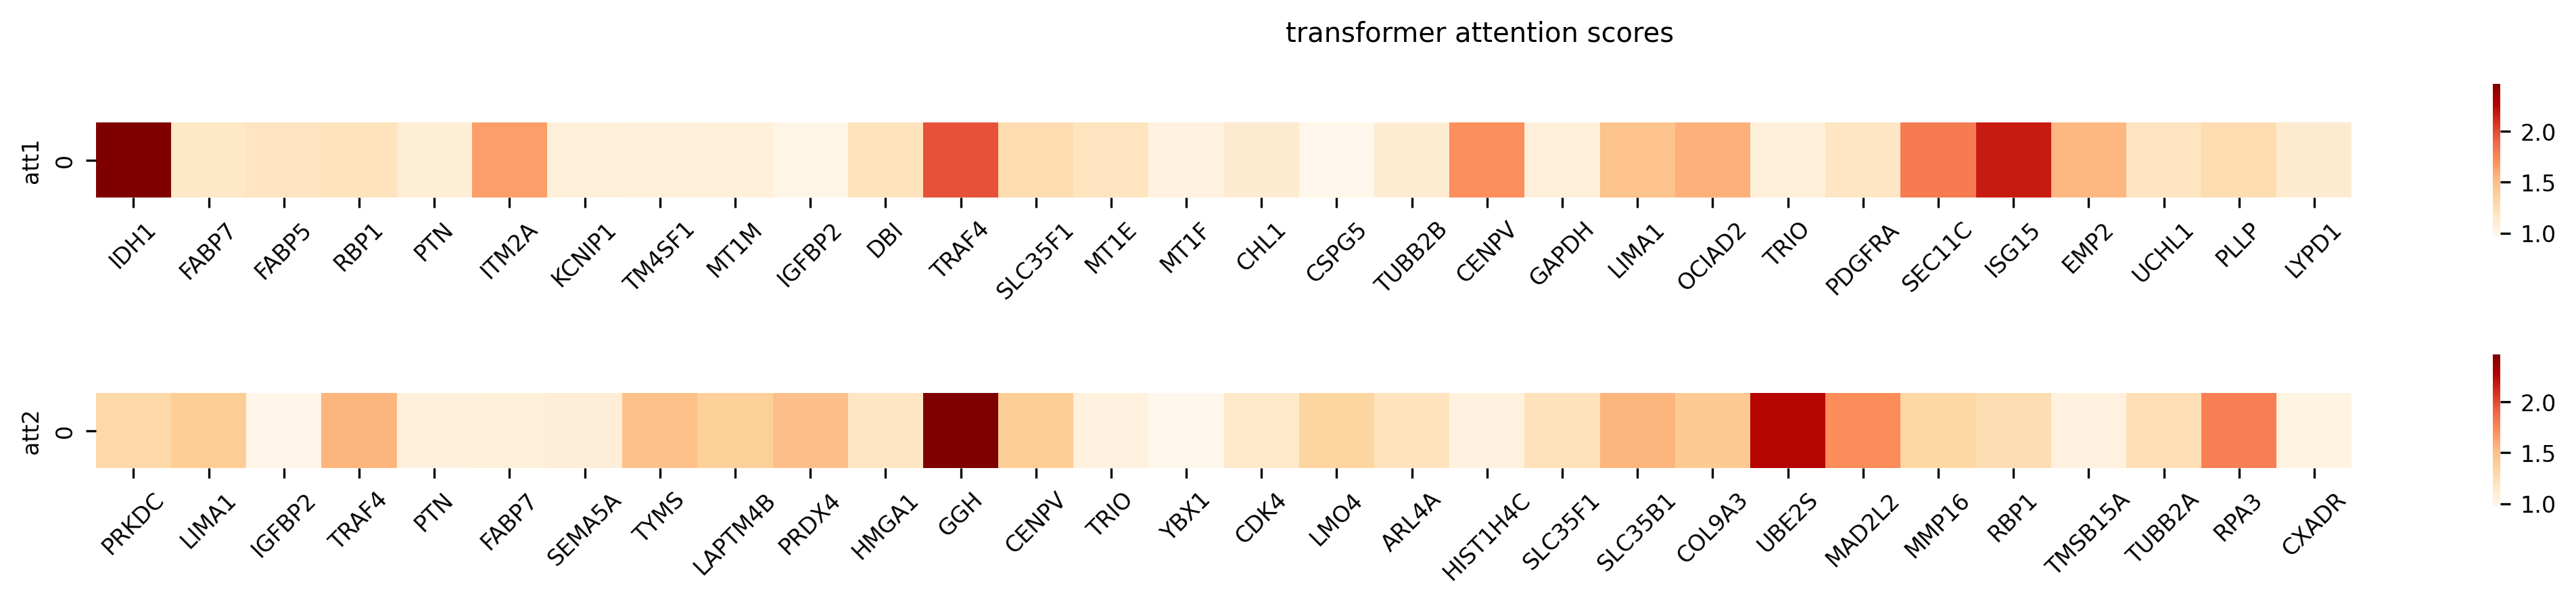

In [30]:
plot_att_vec(trans_att_all)

plot distributions

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [14]:
def plot_att_boxplot(array_list):
    """
    Plots a grid of box plots for a list of (r, c)-shaped arrays.
    
    Parameters:
        array_list (List[np.ndarray]): A list of n arrays, each of shape (r, c).
    """
    n = len(array_list)
    r, c = array_list[0].shape

    # Prepare DataFrame for seaborn
    data_records = []
    for idx, arr in enumerate(array_list):
        for i in range(r):
            for j in range(c):
                data_records.append({
                    'row': i,
                    'col': j,
                    'value': arr[i, j],
                    'index': idx  # optional identifier
                })

    df = pd.DataFrame(data_records)

    # Create shared-y-axis subplot grid
    fig, axs = plt.subplots(r, c, figsize=(2 * c, 6 * r), sharey=True, squeeze=False)

    for i in range(r):
        if  i==0 or i==3:
            genes = gene_sent_geneA
        elif i==1 or i==2:
            genes = gene_sent_geneB

        for j in range(c):
            ax = axs[i, j]
            subset = df[(df['row'] == i) & (df['col'] == j)]
            sns.boxplot(data=subset, x='col', y='value', ax=ax)
            ax.set_xlabel('')
            ax.set_xticks([])
            ax.set_title(genes[j], fontsize=15)
    
    if r==4:
        y_tick = ["att11", "att22", "att12", "att21"]
    elif r==2:
        y_tick = ["att1", "att2"]
    for i in range(r):
        axs[i,0].set_ylabel(y_tick[i], fontsize=15)

    plt.tight_layout()
    plt.show()

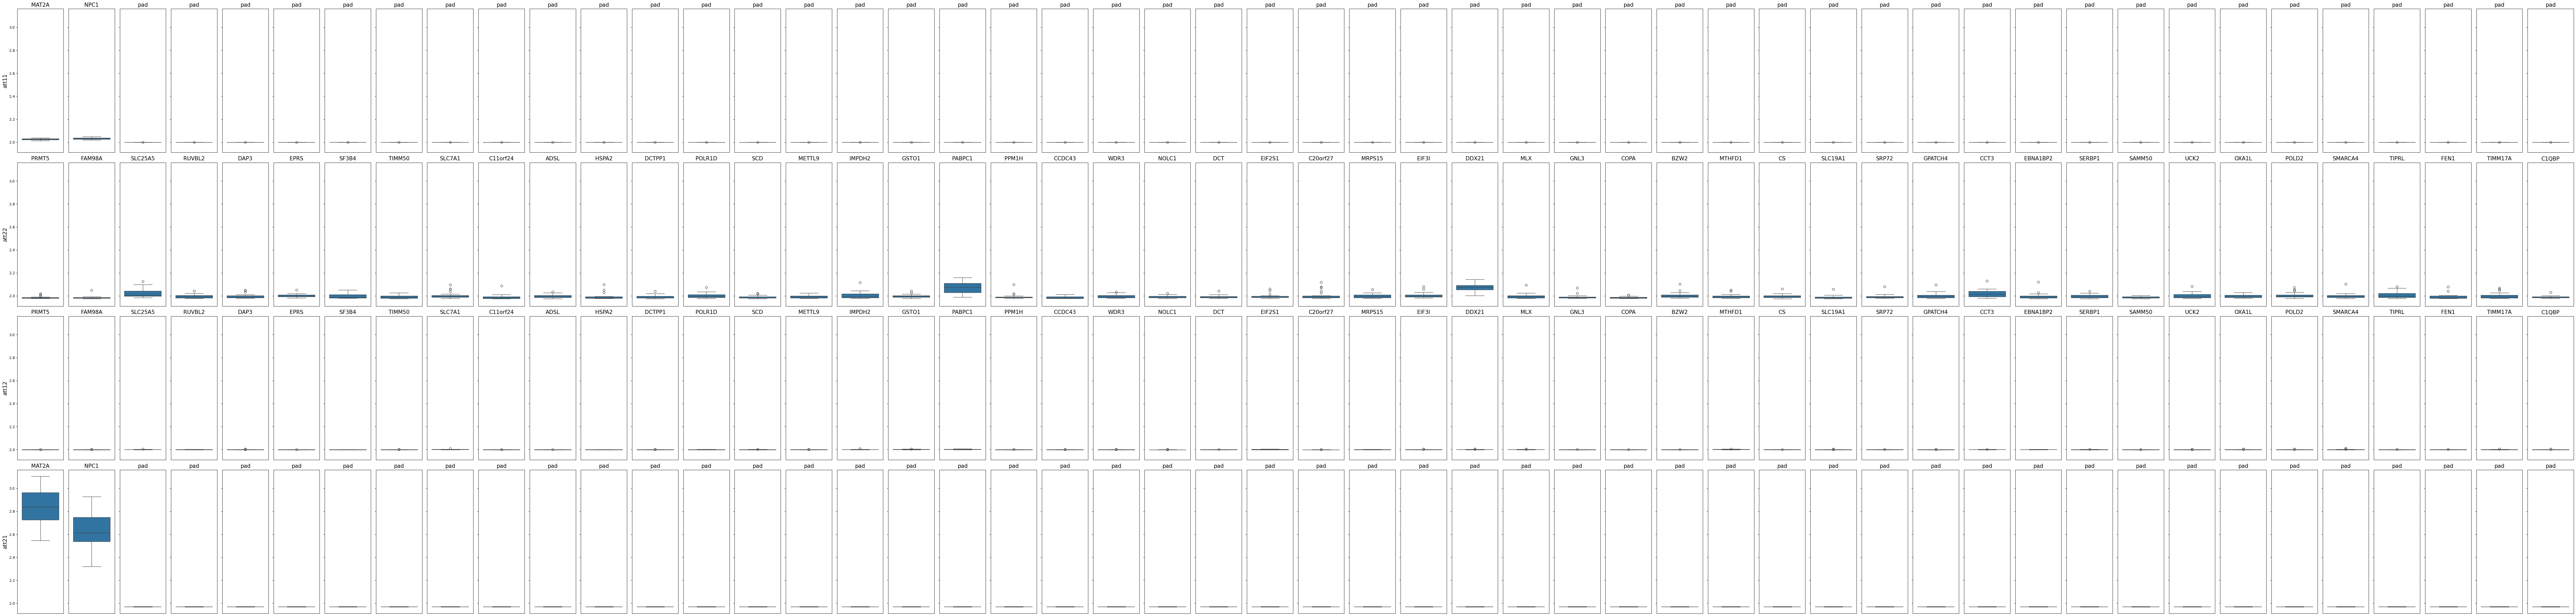

In [25]:
plot_att_boxplot(cross_att_all)

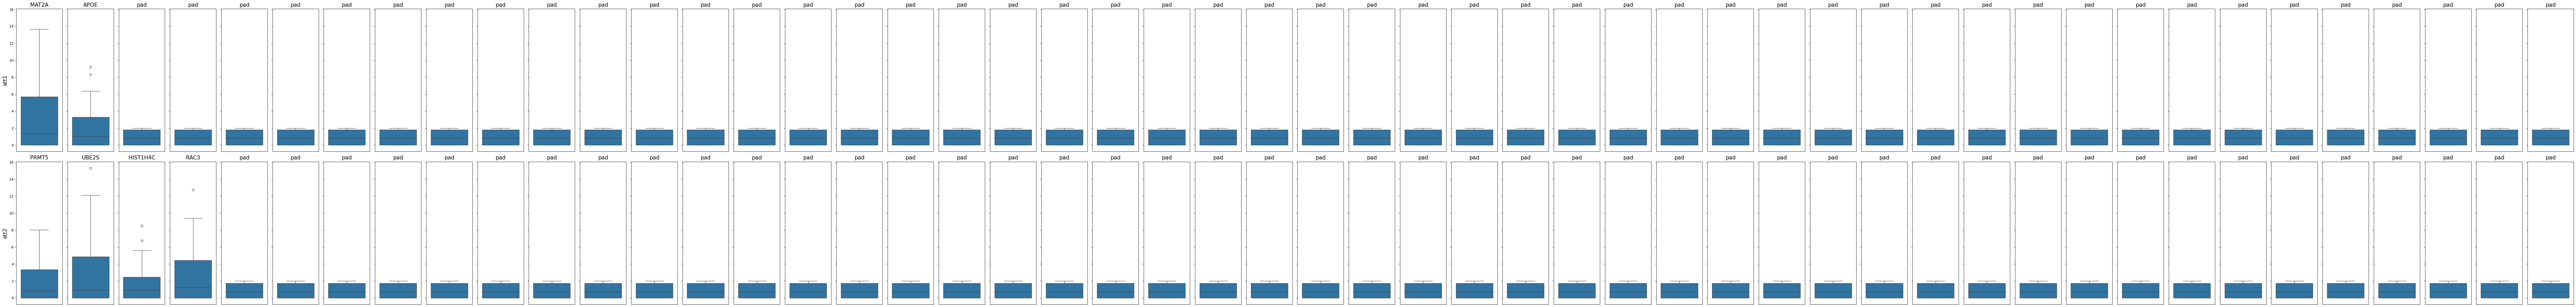

In [18]:
plot_att_boxplot(trans_att_all)

Pathway enrichment for high attention genes

In [70]:
with open("/home/jienihu/sc/SLformer/data/saved_data/map/cancer_list.txt") as f:
    cancer_list = [line.rstrip('\n') for line in f]
cancer2id_map = {cancer:i for i,cancer in enumerate(cancer_list)}

In [71]:
def read_att_model(res_dir, sent_len=50):

    base_dir = "/home/jienihu/sc/SLformer"
    cross_att_all = []
    trans_att_all = []
    model_counts = 0

    for i in range(24):
        name = f"model_no_{i}"
        with open(os.path.join(base_dir + '/' + config.task.model[name], 'params.json'), 'r') as f:
            model_params = json.load(f)
        if model_params["n"] == sent_len:
            cross_att_vec, trans_att_vec = get_gene_att_score(res_dir, name)
            # cross_att_all += np.vstack(cross_att_vec)
            # trans_att_all += np.vstack(trans_att_vec)
            cross_att_all.append(np.vstack(cross_att_vec))
            trans_att_all.append(np.vstack(trans_att_vec))
            model_counts += 1

    return cross_att_all, trans_att_all

In [88]:
CANCER='LUAD'
# res_dir = f"/home/jienihu/sc/SLformer/experiment/att/BRCA_PARP_att_50_{CANCER}"
# res_dir = "/home/jienihu/sc/SLformer/experiment/att/IDH1_PRKDC_att_50"
res_dir = "/home/jienihu/sc/SLformer/experiment/att/KRAS_TBK1_att_50_LUAD"

cross_att_all, trans_att_all = read_att_model(
    res_dir=res_dir,
    sent_len=50
)

cancer_id = cancer2id_map[CANCER]
# gene_sent_geneB = get_gene_sent("PARP1", cancer=cancer_id, n=50)
# print(gene_sent_geneB)
# gene_sent_geneA = get_gene_sent("BRCA2", cancer=cancer_id, n=50)
# print(gene_sent_geneA)
# gene_sent_geneB = get_gene_sent("PRKDC", cancer=cancer_id, n=50)
# print(gene_sent_geneB)
# gene_sent_geneA = get_gene_sent("IDH1", cancer=cancer_id, n=50)
# print(gene_sent_geneA)
gene_sent_geneB = get_gene_sent("TBK1", cancer=cancer_id, n=50)
gene_sent_geneA = get_gene_sent("KRAS", cancer=cancer_id, n=50)

print(gene_sent_geneA)
print(gene_sent_geneB)

['KRAS', 'SLC39A11', 'REXO2', 'APOL6', 'TSR3', 'MARCH6', 'ARHGDIA', 'RAB5C', 'ACOX1', 'TOMM22', 'PACSIN2', 'MAP1LC3B', 'LASP1', 'NCSTN', 'NSF', 'YWHAG', 'HSPA4', 'BAG1', 'TXNRD1', 'LPGAT1', 'FAM84B', 'AIDA', 'GNAI3', 'ARF6', 'DUSP10', 'CTDNEP1', 'PPM1A', 'HSPA9', 'ARL6IP1', 'JTB', 'MAPKAPK2', 'PRRC2B', 'CKAP4', 'PTBP3', 'SHC1', 'MED10', 'ACSL3', 'DEDD2', 'GOLPH3', 'PARP1', 'CASP7', 'DCBLD2', 'UBE2D2', 'CTNNA1', 'HTATIP2', 'CPNE3', 'pad', 'pad', 'pad', 'pad']
['TBK1', 'COLEC11', 'KCNMB4', 'SLC7A2', 'BAALC', 'TMED7', 'RET', 'DUSP10', 'KIT', 'SLC25A21', 'CHST1', 'RBM27', 'AFF4', 'GOT1', 'TMED2', 'LIF', 'NPW', 'HOXB2', 'SCIN', 'YRDC', 'GRAMD4', 'ARL5B', 'HSP90B1', 'SRPK1', 'ARHGAP5', 'SPTSSA', 'LIFR', 'PRDX3', 'NPAS3', 'ARHGAP26', 'PDCD2', 'PTGS2', 'PITPNC1', 'ARFGAP3', 'GOLM1', 'RHOU', 'PDIA2', 'PLK2', 'CBX5', 'TNFAIP3', 'SLC7A11', 'MAGT1', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad']


In [83]:
print(len(cross_att_all))
print(cross_att_all[0].shape)

24
(4, 50)


In [84]:
from scipy.stats import ttest_1samp

In [76]:
def att_pval(att_all, sent_len=50):

    ## convert to a np array, shape (n_models, 4, sent_len)
    att_all = np.array(att_all)
    pval_mtx = np.ones((4, sent_len))
    for group in range(4):
        overall_mean = np.mean(np.array(att_all)[:,group,:])
        for i in range(sent_len):
            att_gene = [att_all[j][group][i] for j in range(len(att_all))]
            t_stat, p_val = ttest_1samp(att_gene, overall_mean)
            if t_stat > 0:
                pval_mtx[group, i] = p_val

    return pval_mtx

In [85]:
pval_mtx = att_pval(cross_att_all)

In [86]:
## group genes based on siginificant p-values
pval_thr = 5e-2

sig = pval_mtx < pval_thr
geneA_sig = np.array([x or y for x,y in zip(sig[0], sig[3])])
geneB_sig = np.array([x or y for x,y in zip(sig[1], sig[2])])

In [89]:
save_dir = "/home/jienihu/sc/SLformer/experiment/att_pval"
# geneA = "BRCA2"; geneB = "PARP1"
# geneA = "IDH1"; geneB = "PRKDC"
geneA = "KRAS"; geneB = "TBK1"

geneA_sig_pos = np.array(gene_sent_geneA)[geneA_sig]
geneA_sig_neg = np.array(gene_sent_geneA)[~geneA_sig]
## remove 'pad's
geneA_sig_pos = np.array([i for i in geneA_sig_pos if i != 'pad'])
geneA_sig_neg = np.array([i for i in geneA_sig_neg if i != 'pad'])
np.savetxt(os.path.join(save_dir, f"{geneA}_{CANCER}_pos.txt"), geneA_sig_pos, fmt="%s")
np.savetxt(os.path.join(save_dir, f"{geneA}_{CANCER}_neg.txt"), geneA_sig_neg, fmt="%s")

geneB_sig_pos = np.array(gene_sent_geneB)[geneB_sig]
geneB_sig_neg = np.array(gene_sent_geneB)[~geneB_sig]
## remove 'pad's
geneB_sig_pos = np.array([i for i in geneB_sig_pos if i != 'pad'])
geneB_sig_neg = np.array([i for i in geneB_sig_neg if i != 'pad'])
np.savetxt(os.path.join(save_dir, f"{geneB}_{CANCER}_pos.txt"), geneB_sig_pos, fmt="%s")
np.savetxt(os.path.join(save_dir, f"{geneB}_{CANCER}_neg.txt"), geneB_sig_neg, fmt="%s")


Using gseapy for pathway enrichment

In [7]:
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt

df_database = pd.DataFrame([
    ['GO_Biological_Process_2021', 6036],
    ['GO_Molecular_Function_2021', 1274],
    ['Reactome_2022', 1818],
    ['KEGG_2021_Human', 332] ####
], columns=['dataset', 'term'])

In [8]:
def read_sig_genelist(geneA, geneB, cancer):

    save_dir = "/home/jienihu/sc/SLformer/experiment/att_pval"
    geneA_sig_pos = np.loadtxt(os.path.join(save_dir, f"{geneA}_{cancer}_pos.txt"), dtype=str).tolist()
    geneA_sig_neg = np.loadtxt(os.path.join(save_dir, f"{geneA}_{cancer}_neg.txt"), dtype=str).tolist()
    geneB_sig_pos = np.loadtxt(os.path.join(save_dir, f"{geneB}_{cancer}_pos.txt"), dtype=str).tolist()
    geneB_sig_neg = np.loadtxt(os.path.join(save_dir, f"{geneB}_{cancer}_neg.txt"), dtype=str).tolist()

    return geneA_sig_pos, geneA_sig_neg, geneB_sig_pos, geneB_sig_neg

In [9]:
## exmaple
# geneA = "BRCA2"
# geneB = "PARP1"
# cancer = "BRCA"

# geneA = "BRCA2"
# geneB = "PARP1"
# cancer = "OV"

geneA = "IDH1"
geneB = "PRKDC"
cancer = "Glioma"

# geneA = "KRAS"
# geneB = "TBK1"
# cancer = "LUAD"

geneA_sig_pos, geneA_sig_neg, geneB_sig_pos, geneB_sig_neg = read_sig_genelist(geneA, geneB, cancer)

In [27]:

def enrich_diff(pos_list, neg_list):

    # databases = ['Reactome_2022']
    # databases = ["KEGG_2021_Human"]
    # databases = ['GO_Biological_Process_2021', 'GO_Molecular_Function_2021']
    databases = ['GO_Biological_Process_2021']
    m = df_database[df_database['dataset'].isin(databases)]['term'].sum()
    p_thresh = 0.05 / m  # Bonferroni correction
    print(f"Bonferroni-corrected p-value threshold: {p_thresh:.4e}")

    enr_result_pos = gp.enrichr(
        gene_list=pos_list,
        gene_sets=databases,
        organism='Human',
        # outdir=outdir,
        cutoff=0.5,  ## 0.5
    )

    result_df_pos = enr_result_pos.results
    filtered_df_pos = result_df_pos
    # filtered_df_pos = result_df_pos[result_df_pos['P-value'] < p_thresh]
    # filtered_df_pos = result_df_pos[result_df_pos['Adjusted P-value'] < 0.05]

    enr_result_neg = gp.enrichr(
        gene_list=neg_list,
        gene_sets=databases,
        organism='Human',
        # outdir=outdir,
        cutoff=0.5,  ## 0.5
    )

    result_df_neg = enr_result_neg.results
    # filtered_df_neg = result_df_neg
    filtered_df_neg = result_df_neg[result_df_neg['P-value'] < p_thresh]
    # filtered_df_neg = result_df_neg[result_df_neg['Adjusted P-value'] < 0.05]

    ## Pathways that are enriched in significant genes but not in non-significant genes
    diff_df = filtered_df_pos[~filtered_df_pos['Term'].isin(filtered_df_neg['Term'])]
    ## remove suffix
    diff_df["Term"] = diff_df["Term"].str.replace(r"\sR-HSA.*", "", regex=True)
    diff_df["Term"] = diff_df["Term"].str.replace(r"\s*\(GO:\d+\)", "", regex=True)

    return diff_df

diff_df_geneA = enrich_diff(geneA_sig_pos, geneA_sig_neg)
diff_df_geneB = enrich_diff(geneB_sig_pos, geneB_sig_neg)


Bonferroni-corrected p-value threshold: 8.2836e-06


Bonferroni-corrected p-value threshold: 8.2836e-06


In [28]:
diff_df_geneB.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,positive regulation of double-strand break rep...,2/16,0.000033,0.004441,0,0,317.063492,3273.111441,MAD2L2;PRKDC
1,GO_Biological_Process_2021,error-prone translesion synthesis,2/21,0.000057,0.004441,0,0,233.567251,2280.803907,MAD2L2;RPA3
2,GO_Biological_Process_2021,regulation of ubiquitin protein ligase activity,2/21,0.000057,0.004441,0,0,233.567251,2280.803907,MAD2L2;UBE2S
3,GO_Biological_Process_2021,double-strand break repair,3/164,0.000085,0.004936,0,0,46.183230,432.810218,MAD2L2;PRKDC;RPA3
4,GO_Biological_Process_2021,regulation of double-strand break repair via n...,2/29,0.000111,0.005139,0,0,164.296296,1496.449021,MAD2L2;PRKDC
5,GO_Biological_Process_2021,positive regulation of double-strand break repair,2/40,0.000212,0.007754,0,0,116.672515,986.884747,MAD2L2;PRKDC
6,GO_Biological_Process_2021,translesion synthesis,2/42,0.000234,0.007754,0,0,110.827778,926.563103,MAD2L2;RPA3
7,GO_Biological_Process_2021,telomere organization,2/47,0.000293,0.008505,0,0,98.488889,801.141933,PRKDC;RPA3
8,GO_Biological_Process_2021,telomere maintenance,2/56,0.000417,0.010742,0,0,82.037037,638.505775,PRKDC;RPA3
9,GO_Biological_Process_2021,DNA repair,3/298,0.000494,0.011472,0,0,25.034746,190.564362,MAD2L2;PRKDC;RPA3


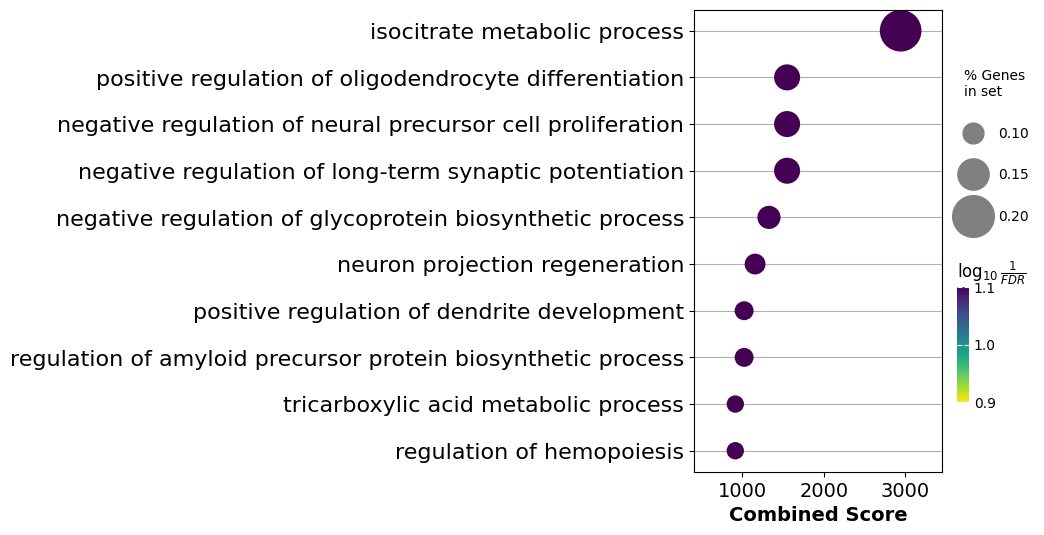

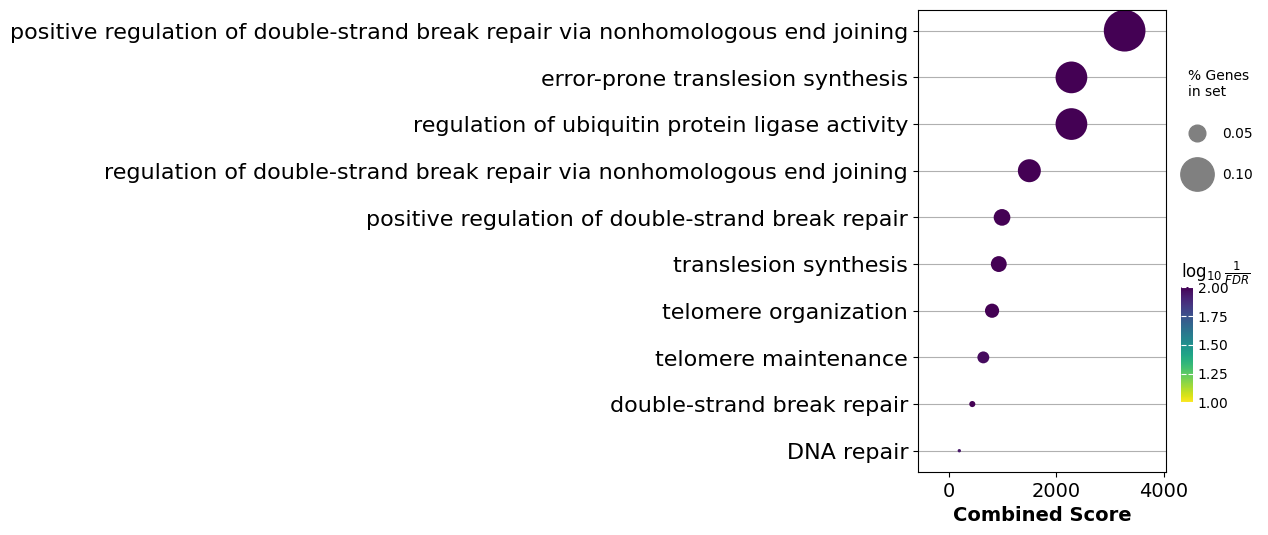

In [29]:
plt_save_dir = "/home/jienihu/sc/SLformer/experiment/att_pval/fig"
axA = gp.dotplot(diff_df_geneA, 
           size=25,
           figsize=(4,6),
           top_term=10,
           cutoff=0.5,
        #    title="BRCA2-PARP1"
           )
# axA = gp.barplot(diff_df_geneA)
figA = axA.get_figure()
figA.savefig(os.path.join(plt_save_dir,f"{geneA}_{cancer}cancer_GO.pdf"), dpi=300, bbox_inches='tight')

axB = gp.dotplot(diff_df_geneB, 
           size=40,
           figsize=(4,6),
           top_term=10,
           cutoff=0.5,
        #    title="BRCA2-PARP1"
           )
# axB = gp.barplot(diff_df_geneB)
figB = axB.get_figure()
figB.savefig(os.path.join(plt_save_dir,f"{geneB}_{cancer}cancer_GO.pdf"), dpi=300, bbox_inches='tight')
